# MicroLive: Example for Protein Diffusion Analysis.

___
This notebook demonstrates how to use MicroLive programmatically for processing mature protein diffusion analysis.

The used dataset is obtained from the following publication: <br>
Zhao, N., Kamijo, K., Fox, P.D., Oda, H., Morisaki, T., Sato, Y., Kimura, H., and Stasevich, T.J., 2019. A genetically encoded probe for imaging nascent and mature HA-tagged proteins in vivo. Nature Communications, 10(1), p.2947. https://doi.org/10.1038/s41467-019-10846-1 

----

This repository contains fluorescent images is accesible at: https://doi.org/10.6084/m9.figshare.8072438

----

### Experimental Imaging Conditions
| Parameter | Value | Description |
| :--- | :--- | :--- |
| **Microscope** | Custom HILO | Widefield fluorescence microscope with inclined illumination |
| **Field of View (FOV)** | 33.3 × 33.3 µm² | 256 × 256 pixels |
| **XY Pixel Size (nm)** | 130 nm | pixel size in XY plane |
| **Integration Time** | 30 ms | Camera exposure time per frame |
| **Frame Rate** | ~22.8 fps | 43.8 ms per image |
| **Total Duration** | 7.3 min | 10,000 time points |
| **Excitation Laser** | 561 nm (7.7 mW) | Imaging laser for Halo-TMR |
| **Photoactivation** | 405 nm (6.2 mW) | Pulsed for 50 ms every 10 s |
| **Track Filter (Length)** | ≥ 16 frames | Minimum track duration |
| **Track Filter (Step)** | < 220 nm | Maximum jump distance between frames |

-----

The selected image is a 2D dataset with 10,000 frames. <br>
Fig.5 and Supplementary Fig.5_Cell01.tif 

# Implementation Overview:

----
- Import libraries and configure paths
- Load microscopy images (TIFF or LIF)
- Cytosol segmentation
- 2D Spot detection
- Particle tracking analysis
- Mean square displacement (MSD) analysis
- Diffusion coefficient calculation

-----

### Load modules
----

In [1]:
"""
MicroLive Notebook
==================
This notebook requires MicroLive to be installed:
    pip install microlive

For development mode:
    pip install -e /path/to/microlive
"""
# MicroLive imports
from microlive import microscopy as mi
from microlive.utils.device import check_gpu_status

# Verify GPU support
check_gpu_status()

# Standard scientific imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


MicroLive loaded from: /Users/nzlab-la/Desktop/microlive


In [ ]:
# Load the image
tif_image_path = Path("/Users/nzlab-la/Desktop/microlive/notebooks/examples/revision_data/Zhao_2019/raw_images/Fig.5 and Supplementary Fig.5_Cell10.tif")
raw_image = tifffile.imread(str(tif_image_path))
print(f"Loaded TIFF with shape: {raw_image.shape}") # (T, Y, X)

Loaded TIFF with shape: (10000, 256, 256)


In [3]:
# Set the axis order that matches YOUR file
input_axis_order = ['T', 'Y', 'X']  
# Convert to MicroLive's standard format [T, Z, Y, X, C]
converter = mi.ConvertFormat(
    image=raw_image,
    original_order=input_axis_order,
    desired_order=['T', 'Z', 'Y', 'X', 'C']
)
image_stack = converter.convert()
print(f"Converted to MicroLive format [T, Z, Y, X, C]: {image_stack.shape}") # the converted added a T dimension with a single time point.

Converted to MicroLive format [T, Z, Y, X, C]: (10000, 1, 256, 256, 1)


### Define Image Metadata
-----

In [4]:
# Physical parameters (adjust to your microscope settings)
pixel_size_xy_nm = 130  # Pixel size in nanometers (XY)
voxel_size_z_nm = 500   # Voxel size in nanometers (Z) - Single z-frame. 
time_interval_sec = 0.043  # Time between frames in seconds - This image contains a single timepoint.

# For MicroLive classes
list_voxels = [voxel_size_z_nm, pixel_size_xy_nm]  # [Z, YX]

# Extract dimensions from the correctly formatted image
n_timepoints = image_stack.shape[0]
n_zslices = image_stack.shape[1]
height_y = image_stack.shape[2]
width_x = image_stack.shape[3]
n_channels = image_stack.shape[4]

print(f"Image dimensions (TZYXC format):")
print(f"  Time points (T): {n_timepoints}")
print(f"  Z-slices (Z): {n_zslices}")
print(f"  Height (Y): {height_y} px")
print(f"  Width (X): {width_x} px")
print(f"  Channels (C): {n_channels}")
print(f"\nPhysical scale:")
print(f"  Pixel size: {pixel_size_xy_nm} nm")
print(f"  Z-step: {voxel_size_z_nm} nm")
print(f"  Frame interval: {time_interval_sec} sec")

Image dimensions (TZYXC format):
  Time points (T): 10000
  Z-slices (Z): 1
  Height (Y): 256 px
  Width (X): 256 px
  Channels (C): 1

Physical scale:
  Pixel size: 130 nm
  Z-step: 500 nm
  Frame interval: 0.043 sec


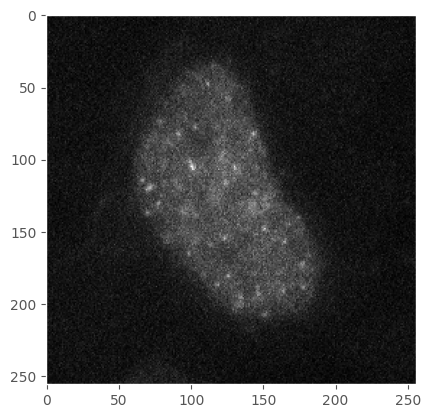

In [5]:
# plot a maximum projection of the image stack# Assuming img has dimensions (T, Z, Y, X, C)
vmax = np.percentile(image_stack,99.9)
vmin = np.percentile(image_stack, 1.0)
plt.imshow(image_stack[0, 0,  :,:, 0], cmap='gray', vmin=vmin, vmax=vmax)
plt.axis('on')
plt.grid(False)
plt.show()


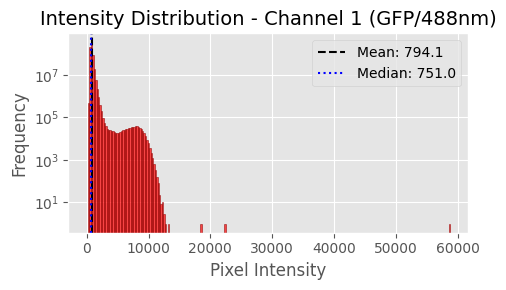

Min: 298, Max: 58746, Mean: 794.14


In [6]:
# Visualize the intensity distribution of the channel with spots
selected_channel_data = image_stack[...,0].flatten()
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(selected_channel_data, bins=256, range=(0, selected_channel_data.max()), 
        color='red', alpha=0.7, edgecolor='darkred', linewidth=0.5)
ax.set_xlabel('Pixel Intensity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Intensity Distribution - Channel 1 (GFP/488nm)', fontsize=14)
ax.set_yscale('log')  
ax.axvline(np.mean(selected_channel_data), color='black', linestyle='--', label=f'Mean: {np.mean(selected_channel_data):.1f}')
ax.axvline(np.median(selected_channel_data), color='blue', linestyle=':', label=f'Median: {np.median(selected_channel_data):.1f}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Min: {selected_channel_data.min()}, Max: {selected_channel_data.max()}, Mean: {np.mean(selected_channel_data):.2f}")

### Perform cytosol segmentation using cellpoose
___

Running cytosol segmentation...
Model cyto3 loaded
Cytosol: 1 cells detected


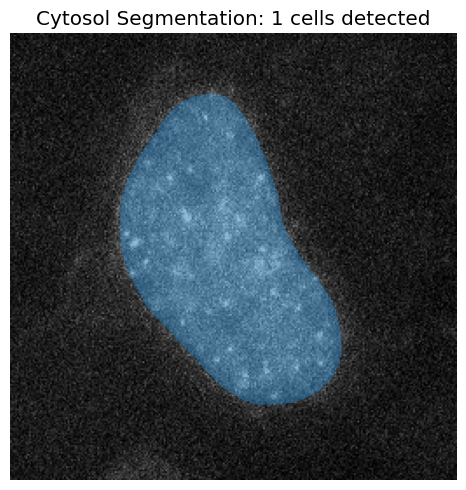

In [ ]:
# Cellpose Segmentation - Matching GUI Behavior
cytosol_channel = 0   # Channel index for cytosol segmentation
diameter_cytosol = 150  # Average cytosol diameter in pixels
img_slice = image_stack[0, 0, :, :, :]  # image shape is [T, Z, Y, X, C] -> [ Y, X, C]

# Cytosol Segmentation (using cyto3 model)
print("Running cytosol segmentation...")
segmenter_cyto = mi.CellSegmentation(
    img_slice ,
    channels_cytosol=[cytosol_channel],
    channels_nucleus=None,  # Only cytosol
    diameter_cytosol=diameter_cytosol,
    model_cyto_segmentation='cyto3',  # Default model for cytosol
    selection_metric=None,
    running_in_pipeline=True,
    show_plot=False
)
mask_cytosol, _, _ = segmenter_cyto.calculate_masks()
print(f"Cytosol: {np.max(mask_cytosol) if mask_cytosol is not None else 0} cells detected")

# Plot results
fig, ax = plt.subplots(figsize=(5, 5))
max_proj_cyto = img_slice[:, :, cytosol_channel]
vmax = np.percentile(max_proj_cyto,99.9)
vmin = np.percentile(max_proj_cyto, 1.0)
ax.imshow(max_proj_cyto, cmap='gray', vmin=vmin, vmax=vmax)
if mask_cytosol is not None and np.max(mask_cytosol) > 0:
    cytosol_overlay = np.ma.masked_where(mask_cytosol == 0, mask_cytosol)
    ax.imshow(cytosol_overlay, cmap='tab20', alpha=0.5)
ax.set_title(f'Cytosol Segmentation: {np.max(mask_cytosol) if mask_cytosol is not None else 0} cells detected')
ax.axis('off')
plt.tight_layout()
plt.show()


### 2D Spot Detection with Pre-computed Masks
____

In [8]:
# Tracking parameters
tracking_params = {
    'channels_spots': [0],           # Channel to detect spots in
    'channels_cytosol': [0],         # Cytosol channel for background
    'channels_nucleus': [None],      # Nucleus channel (None if not applicable)
    'threshold_for_spot_detection': 200,  # Detection threshold
    'yx_spot_size_in_px': 5,         # Expected spot size in pixels
    'z_spot_size_in_px': 1,          # Spot size in Z
    'cluster_radius_nm': 500,        # Cluster detection radius
    'min_length_trajectory': 100,     # Minimum trajectory length (frames)
    'maximum_range_search_pixels': 3,  # Max displacement between frames
    'memory': 1,                     # Frames to remember for linking
    'link_using_3d_coordinates': False,
    'use_maximum_projection': True,
}
# Create binary mask from labeled mask
binary_mask = (mask_cytosol > 0).astype(bool)
# Run particle tracking
tracker = mi.ParticleTracking(
    image=image_stack,
    list_voxels=list_voxels,
    masks=binary_mask,
    step_size_in_sec=time_interval_sec,
    **tracking_params
)
# Get tracking results
list_dataframes, _ = tracker.run()
# Combine all dataframes
df_tracking = list_dataframes[0] if list_dataframes else pd.DataFrame()
print(f"\nTracking Results:")
print(f"  Total spots detected: {len(df_tracking)}")
print(f"  Unique trajectories: {df_tracking['particle'].nunique() if 'particle' in df_tracking.columns else 0}")
# Preview dataframe
if not df_tracking.empty:
    print("\nDataFrame columns:")
    print(df_tracking.columns.tolist())
    display(df_tracking.head())

[ParticleTracking._normalize_mask_to_tyx] Input mask shape: (256, 256), ndim: 2, T=10000
[ParticleTracking] Expanding YX mask (256, 256) to TYX [10000, 256, 256] (static mask across all frames)

Tracking Results:
  Total spots detected: 14009
  Unique trajectories: 96

DataFrame columns:
['image_id', 'cell_id', 'nuc_loc_y', 'nuc_loc_x', 'cyto_loc_y', 'cyto_loc_x', 'nuc_area_px', 'cyto_area_px', 'cell_area_px', 'z', 'y', 'x', 'is_nuc', 'is_cluster', 'cluster_size', 'spot_type', 'is_cell_fragmented', 'nuc_int_ch_0', 'cyto_int_ch_0', 'complete_cell_int_ch_0', 'pseudo_cyto_int_ch_0', 'nuc_cyto_int_ratio_ch_0', 'nuc_pseudo_cyto_int_ratio_ch_0', 'spot_int_ch_0', 'psf_amplitude_ch_0', 'psf_sigma_ch_0', 'snr_ch_0', 'total_spot_int_ch_0', 'spot_size_ch_0', 'frame', 'time', 'particle']


,image_id,cell_id,nuc_loc_y,nuc_loc_x,cyto_loc_y,cyto_loc_x,nuc_area_px,cyto_area_px,cell_area_px,z,...,nuc_pseudo_cyto_int_ratio_ch_0,spot_int_ch_0,psf_amplitude_ch_0,psf_sigma_ch_0,snr_ch_0,total_spot_int_ch_0,spot_size_ch_0,frame,time,particle
0,0,0,0,0,128,123,0,14489,14489,0.0,...,0.0,376.7583,2231.0,1.3430,1.5362,52820.0,3.1625,1,0.043,0
1,0,0,0,0,128,123,0,14489,14489,0.0,...,0.0,400.3683,1659.0,1.2387,1.2510,60254.0,2.9169,1,0.043,1
2,0,0,0,0,128,123,0,14489,14489,0.0,...,0.0,505.4417,1675.0,1.1695,2.2253,61185.0,2.7540,2,0.086,1
3,0,0,0,0,128,123,0,14489,14489,0.0,...,0.0,370.1383,1641.0,1.2071,1.3538,53142.0,2.8425,3,0.129,0
4,0,0,0,0,128,123,0,14489,14489,0.0,...,0.0,570.9650,1838.0,1.1511,2.1675,62096.0,2.7106,3,0.129,1


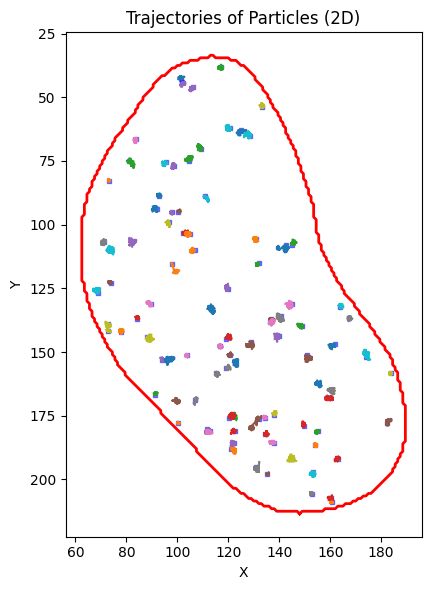

In [11]:
# Plot the detected spots in the image
plotter = mi.Plots()
plotter.plot_trajectories_and_mask(
    df=df_tracking,
    masks=mask_cytosol,
    filtered_image=image_stack[:, :, :, :, 0],  # [T, Z, Y, X] for channel 0
    plot_type='2d',       
    figsize=(6, 6),
    show_legend=False,
    max_percentile=99.7,
    time_point=0,     
    save_plots=False
)

### Calculate the MSD
___

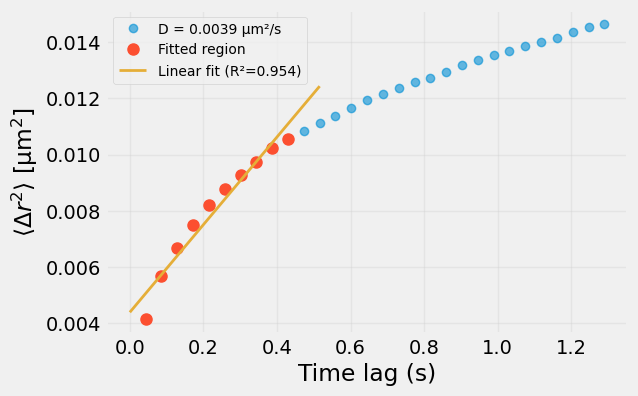


Diffusion coefficient: 0.0039 µm²/s


In [10]:
# MSD parameters
microns_per_pixel = pixel_size_xy_nm / 1000  # Convert nm to µm
max_lagtime = 30  # Maximum lag time in frames

# Calculate MSD
msd_analyzer = mi.ParticleMotion(
    trackpy_dataframe=df_tracking,
    microns_per_pixel=microns_per_pixel,
    step_size_in_sec=time_interval_sec,
    max_lagtime=max_lagtime,
    show_plot=True,
    is_3d=False,  # Set to True for 3D MSD
    max_fit_points=10
)

# Get diffusion coefficient
diffusion_coeff, msd_data,  _, _, _, _ ,_= msd_analyzer.calculate_msd()
print(f"\nDiffusion coefficient: {diffusion_coeff:.4f} µm²/s")
